# AIM 1: peak widths across occupancy bins

In [1]:
import pybedtools
from pybedtools import BedTool
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import *
import os

load files

In [2]:
genome = 'GRCh38_EBV.chrom.sizes.tsv'

h3k4me3_name = 'K562_H3K4me3.bed'
h3k27ac_name = 'K562_H3K27ac.bed'
h3k27me3_name = 'K562_H3k27me3.bed'
h3k9me3_name = 'K562_H3K9me3.bed'

# saved to named files so the marks do not depend on pybedtools temp files, which cleanup() or the os can delete
marks = {
    'H3K4me3': BedTool(h3k4me3_name).sort(g=genome).saveas('H3K4me3.sorted.bed'), # active
    'H3K27ac': BedTool(h3k27ac_name).sort(g=genome).saveas('H3K27ac.sorted.bed'), # active
    'H3K27me3': BedTool(h3k27me3_name).sort(g=genome).saveas('H3K27me3.sorted.bed'), # repressive
    'H3K9me3': BedTool(h3k9me3_name).sort(g=genome).saveas('H3K9me3.sorted.bed') # repressive
}

for name, bt in marks.items():
    print(bt.count(), name, 'peaks')

21445 H3K4me3 peaks
52334 H3K27ac peaks
163784 H3K27me3 peaks
5584 H3K9me3 peaks


find regions on the genome, filtered using blacklist regions

separately, find bivalent regions which have active and repressive marks

In [3]:
blacklist = BedTool('hg38-blacklist.v2.bed.gz').sort(g=genome)
blacklist_stable = blacklist.saveas('blacklist.sorted.bed')

clean = BedTool('merged_tf_counts.bed').sort(g=genome).intersect(blacklist, v=True)
n_clean = clean.count()
print(f"{n_clean} 'clean' loci (regions on the genome which exhibit *some* tf binding)")

both_marks = marks['H3K4me3'].intersect(marks['H3K27me3']).sort(g=genome).merge().saveas('bivalent.sorted.bed')
marks = {**marks, 'bivalent': both_marks}

594202 'clean' loci (regions on the genome which exhibit *some* tf binding)


percentile binned design

In [4]:
bin_edges = (0,50,80,90,95,99,100)
quantiles = [i/100 for i in bin_edges]

df_clean = clean.to_dataframe(names=['chrom', 'start', 'end', 'tfs', 'n_tfs'])
bin_edge_values = df_clean['n_tfs'].quantile(quantiles).values

label_text = [f'{bin_edges[i]}-{bin_edges[i+1]}' for i in range(len(bin_edges) - 1)]

df_clean['occupancy_bin'] = pd.cut(
    df_clean['n_tfs'],
    bins = bin_edge_values,
    labels = label_text,
    include_lowest = True,
    duplicates = 'drop'
)

df_clean['occupancy_bin'].value_counts().sort_index()

occupancy_bin
0-50      375483
50-80     112304
80-90      48007
90-95      28740
95-99      23752
99-100      5916
Name: count, dtype: int64

binned loci, bin order and mark colours used throughout the width analysis below

binned_clean is saved to a named file, so the cells below do not depend on a pybedtools temp file

In [5]:
binned_clean = BedTool.from_dataframe(
    df_clean[['chrom', 'start', 'end', 'occupancy_bin']].astype({'occupancy_bin': str})
).sort(g = genome).saveas('binned_clean.bed')

bin_order = list(df_clean['occupancy_bin'].cat.categories)

colour_map = {
    "H3K4me3": "red",  # active
    "H3K27ac": "pink",  # active
    "H3K27me3": "lightblue",  # repressive
    "H3K9me3": "blue",  # repressive
    "bivalent": "purple",  # both
}

we now consider the distribution of peak widths across occupancy bins

if a mark's association with high-occupancy loci reflects the same technical bias as the tf signal, the widths of its peaks at those loci should differ from its widths at ordinary tf-bound loci. but width also shifts for purely geometric reasons: a peak of width w overlaps a locus of length L with probability proportional to (w + L), so wider peaks are over-sampled, and most strongly at short loci. hot loci are longer than other loci, so some change in width across bins is expected by chance alone

each observed distribution is therefore compared against a width-aware null: the same loci (keeping their bin labels and lengths) are shuffled at random and the widths of the peaks that overlap them are recomputed

first, a check of what the peak files look like. a narrowpeak call on a broad mark truncates domains, so width partly reflects the caller rather than the biology

In [6]:
fmt = []
for mark_name, mark_bed in marks.items():
    w = np.array([len(iv) for iv in mark_bed])
    fmt.append({
        'mark': mark_name,
        'n_cols': mark_bed.field_count(),
        'n_peaks': len(w),
        'min_bp': w.min(),
        'p25_bp': np.percentile(w, 25),
        'median_bp': np.median(w),
        'p75_bp': np.percentile(w, 75),
        'max_bp': w.max()
    })

pp(pd.DataFrame(fmt))

       mark  n_cols  n_peaks  min_bp  p25_bp  median_bp   p75_bp  max_bp
0   H3K4me3      10    21445     220  515.00     1181.0  2139.00   11227
1   H3K27ac      10    52334     160  324.00      529.0   991.00   13924
2  H3K27me3      10   163784     295  456.00      644.0  1016.00   30281
3   H3K9me3      10     5584     130  163.00      212.0   292.00    4655
4  bivalent       3     3692       1  292.75      456.0   731.25    4040


observed widths

for each mark, every peak overlapping at least one locus in a bin contributes its width to that bin. a peak overlapping several loci in the same bin is counted once, and a peak spanning loci in several bins is counted in each of them. the bivalent 'peaks' are the merged k4me3 and k27me3 intersections, so their widths are the widths of those merged regions

In [7]:
def peak_widths_by_bin(loci_bt):
    out = []
    for mark_name, mark_bed in marks.items():
        hits = mark_bed.cut([0, 1, 2]).intersect(loci_bt, wa=True, wb=True)
        df = hits.to_dataframe(
            names=['chrom', 'start', 'end', 'l_chrom', 'l_start', 'l_end', 'occupancy_bin']
        )
        df = df.drop_duplicates(['chrom', 'start', 'end', 'occupancy_bin'])
        df['mark'] = mark_name
        df['width'] = df['end'] - df['start']
        out.append(df[['mark', 'occupancy_bin', 'width']])
    return pd.concat(out, ignore_index=True)


widths_obs = peak_widths_by_bin(binned_clean)
widths_obs['log_width'] = np.log10(widths_obs['width'])

print(widths_obs.groupby(['mark', 'occupancy_bin']).size().unstack())

occupancy_bin   0-50  50-80  80-90  90-95  95-99  99-100
mark                                                    
H3K27ac         2110   1864   2742   6238  25438   13956
H3K27me3       38646  16651   8459   4945   2560     316
H3K4me3         5537   2410   1384   1105   1855    1172
H3K9me3          694    774    884    581    518     284
bivalent         784    333    227    138    110       9


width-aware null

shuffle the binned loci (not the marks) n_width_perms times, excluding blacklist regions, then recompute the widths of overlapping peaks in the same way. shuffling the loci keeps each bin's locus lengths fixed, which is what drives the geometric effect described above. each permutation costs one shuffle plus one intersect per mark

In [8]:
n_width_perms = 20

widths_null = []
for i in range(n_width_perms):
    shuffled_loci = binned_clean.shuffle(g=genome, excl=blacklist_stable.fn, chrom=True, seed=i).saveas()
    df = peak_widths_by_bin(shuffled_loci)
    df['perm'] = i
    widths_null.append(df)
    os.remove(shuffled_loci.fn)

widths_null = pd.concat(widths_null, ignore_index=True)
widths_null['log_width'] = np.log10(widths_null['width'])

summary by mark and bin

median_bp is the median width of overlapping peaks, with the shuffled-loci null alongside. w1_vs_null is the wasserstein distance between the observed and null log10 widths: the average gap between matching quantiles, so 0.1 is roughly a 26% change in width. w1_noise is the same distance between a single null permutation and the remaining permutations, i.e. what sampling noise alone produces at this sample size. w1_vs_null needs to clearly exceed w1_noise before it means anything

In [9]:
from scipy.stats import wasserstein_distance

def w1(a, b):
    return wasserstein_distance(a, b) if len(a) and len(b) else np.nan

def median_bp(a):
    return 10 ** np.median(a) if len(a) else np.nan

def noise_floor(perms):
    if len(perms) < 2:
        return np.nan
    return np.mean([w1(p, np.concatenate(perms[:i] + perms[i + 1:])) for i, p in enumerate(perms)])

none = np.array([])
obs_w = {k: g['log_width'].values for k, g in widths_obs.groupby(['mark', 'occupancy_bin'])}
null_w = {k: g['log_width'].values for k, g in widths_null.groupby(['mark', 'occupancy_bin'])}
null_perms = {
    k: [p['log_width'].values for _, p in g.groupby('perm')]
    for k, g in widths_null.groupby(['mark', 'occupancy_bin'])
}

width_summary = []
for mark_name in marks:
    for b in bin_order:
        k = (mark_name, b)
        o, nl = obs_w.get(k, none), null_w.get(k, none)
        width_summary.append({
            'mark': mark_name,
            'occupancy_bin': b,
            'n_peaks': len(o),
            'median_bp': median_bp(o),
            'null_median_bp': median_bp(nl),
            'w1_vs_null': w1(o, nl),
            'w1_noise': noise_floor(null_perms.get(k, []))
        })

width_summary = pd.DataFrame(width_summary)

with pd.option_context('display.width', 200, 'display.max_columns', None):
    pp(width_summary.round(3))

        mark occupancy_bin  n_peaks  median_bp  null_median_bp  w1_vs_null  w1_noise
0    H3K4me3          0-50     5537   1872.000          1905.0       0.006     0.005
1    H3K4me3         50-80     2410   1843.000          1885.0       0.009     0.010
2    H3K4me3         80-90     1384   1808.000          1817.0       0.022     0.013
3    H3K4me3         90-95     1105   1523.000          1757.0       0.048     0.015
4    H3K4me3         95-99     1855   1502.000          1569.0       0.019     0.014
5    H3K4me3        99-100     1172   1638.999          1422.0       0.044     0.021
6    H3K27ac          0-50     2110    410.500           820.0       0.201     0.004
7    H3K27ac         50-80     1864    384.500           781.0       0.240     0.008
8    H3K27ac         80-90     2742    367.500           730.0       0.264     0.011
9    H3K27ac         90-95     6238    398.000           690.0       0.228     0.013
10   H3K27ac         95-99    25438    572.000           626.0   

median width of overlapping peaks by occupancy bin, per mark. dashed lines are the shuffled-loci null for the same mark, so the gap between a solid and dashed line is the part of the width that geometry does not explain

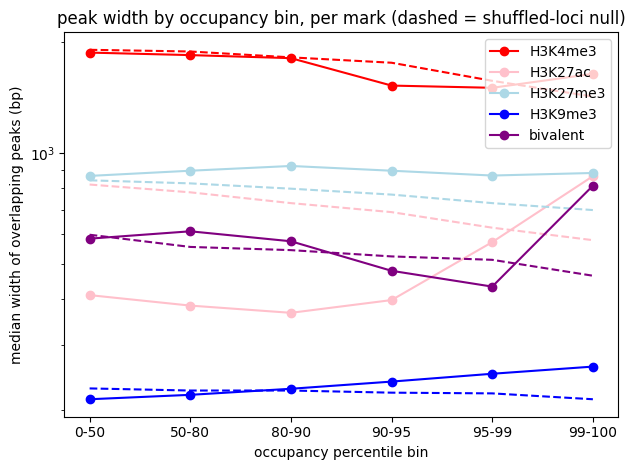

In [ ]:
plt.figure()
for mark_name in marks:
    sub = width_summary[width_summary['mark'] == mark_name].set_index('occupancy_bin').reindex(bin_order)
    plt.plot(bin_order, sub['median_bp'], marker='o', label=mark_name, color=colour_map[mark_name])
    # plt.plot(bin_order, sub['null_median_bp'], linestyle='--', color=colour_map[mark_name])

plt.xlabel('occupancy percentile bin')
plt.ylabel('median width of overlapping peaks (bp)')
plt.yscale('log')
plt.title('peak width by occupancy bin, per mark (dashed = shuffled-loci null)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_peak_width_by_bin.png', dpi=300)
plt.show()

full distributions: ecdf of log10 peak width, one panel per mark and one line per occupancy bin. the black dashed line is the null pooled across bins, so it is a reference rather than a bin-matched comparison (the bin-matched version is w1_vs_null above)

how to read it: parallel shifted curves mean the whole distribution moved; curves that cross mean the shape changed, and a left tail (narrow peaks) that grows with occupancy is the point-source signature

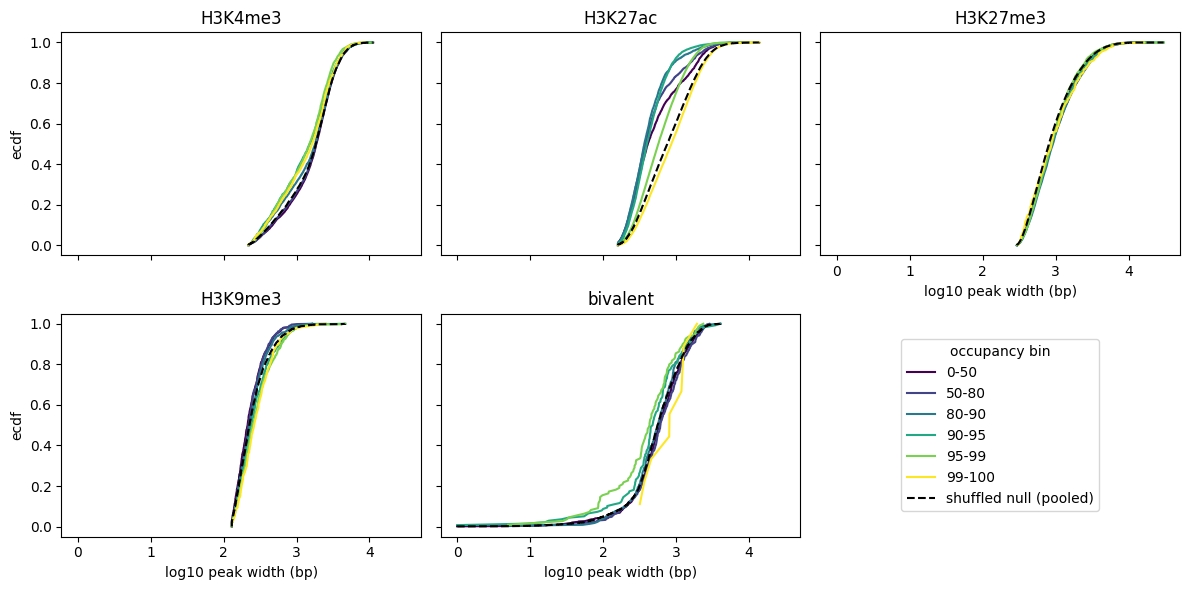

In [11]:
def ecdf(x):
    x = np.sort(x)
    return x, np.arange(1, len(x) + 1) / len(x)

bin_colours = plt.cm.viridis(np.linspace(0, 1, len(bin_order)))

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
axes = axes.ravel()

for ax, mark_name in zip(axes, marks):
    for colour, b in zip(bin_colours, bin_order):
        x = obs_w.get((mark_name, b), none)
        if len(x):
            ax.plot(*ecdf(x), color=colour, label=b)
    pooled_null = widths_null.loc[widths_null['mark'] == mark_name, 'log_width'].values
    ax.plot(*ecdf(pooled_null), color='black', linestyle='--', label='shuffled null (pooled)')
    ax.set_title(mark_name)

# spare panel holds the legend
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, title='occupancy bin', loc='center')
axes[-1].axis('off')

for ax in axes[2:5]:
    ax.set_xlabel('log10 peak width (bp)')
    ax.tick_params(labelbottom=True)
for ax in axes[::3]:
    ax.set_ylabel('ecdf')

plt.tight_layout()
plt.savefig('plot_peak_width_ecdf.png', dpi=300)
plt.show()

lowest vs highest occupancy bin as histograms, to look for a mixture. an ecdf hides modes, whereas a second narrow population that grows with occupancy would pull the median down without moving either component

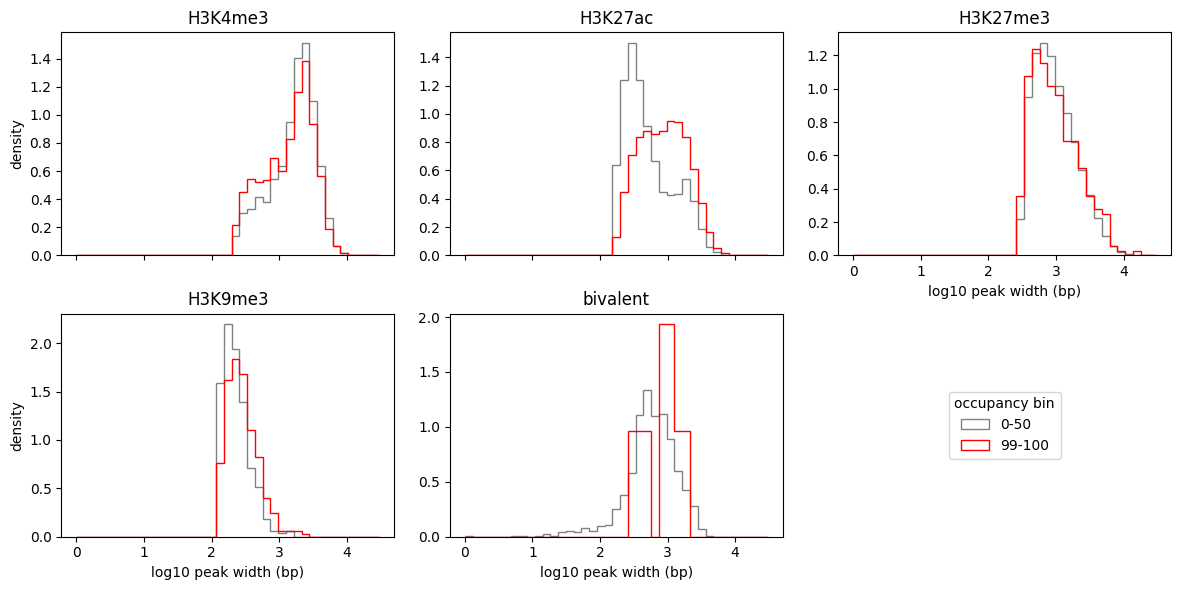

In [12]:
lo_bin, hi_bin = bin_order[0], bin_order[-1]
hist_edges = np.linspace(widths_obs['log_width'].min(), widths_obs['log_width'].max(), 40)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True)
axes = axes.ravel()

for ax, mark_name in zip(axes, marks):
    for b, colour in ((lo_bin, 'grey'), (hi_bin, 'red')):
        x = obs_w.get((mark_name, b), none)
        if len(x):
            ax.hist(x, bins=hist_edges, density=True, histtype='step', color=colour, label=b)
    ax.set_title(mark_name)

handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, title='occupancy bin', loc='center')
axes[-1].axis('off')

for ax in axes[2:5]:
    ax.set_xlabel('log10 peak width (bp)')
    ax.tick_params(labelbottom=True)
for ax in axes[::3]:
    ax.set_ylabel('density')

plt.tight_layout()
plt.savefig('plot_peak_width_hist.png', dpi=300)
plt.show()

ridgeline plot of the same distributions: one panel per mark, one ridge per occupancy bin (lowest at the bottom, highest at the top), x axis log10 peak width. each ridge is a kernel density estimate of the observed widths, the tick inside it marks the median, and the dashed line is the bin-matched shuffled-loci null, so a ridge that departs from its own dashed line is a change geometry does not explain

ridges are scaled to a common height within each panel (not to equal area), and bins with fewer than 5 peaks are left blank because a density estimate from so few points is meaningless. n is shown beside each bin label

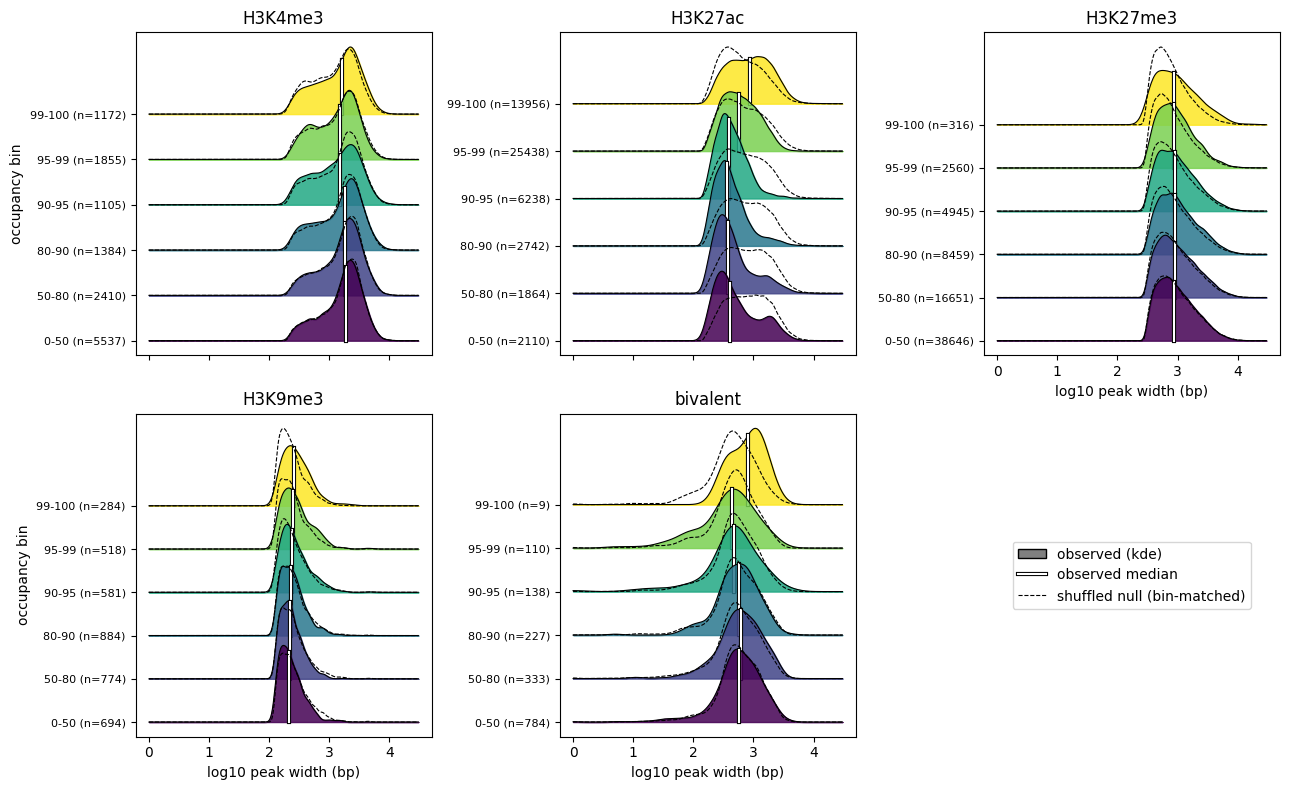

In [ ]:
# WITH NULL

from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.patheffects as pe

median_outline = [pe.withStroke(linewidth=3, foreground='black')]

x_grid = np.linspace(widths_obs['log_width'].min(), widths_obs['log_width'].max(), 300)
bin_colours = plt.cm.viridis(np.linspace(0, 1, len(bin_order)))
overlap = 1.8  # how far the tallest ridge reaches into the one above it

def ridge_density(x):
    if len(x) < 5 or np.std(x) == 0:
        return None
    return gaussian_kde(x)(x_grid)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
axes = axes.ravel()

for ax, mark_name in zip(axes, marks):
    dens_obs = {b: ridge_density(obs_w.get((mark_name, b), none)) for b in bin_order}
    dens_null = {b: ridge_density(null_w.get((mark_name, b), none)) for b in bin_order}
    scale = overlap / max(d.max() for d in [*dens_obs.values(), *dens_null.values()] if d is not None)

    for i, (b, colour) in enumerate(zip(bin_order, bin_colours)):
        z = 10 * (len(bin_order) - i)  # lower ridges drawn in front of higher ones
        if dens_obs[b] is not None:
            top = i + dens_obs[b] * scale
            ax.fill_between(x_grid, i, top, color=colour, alpha=0.85, zorder=z)
            ax.plot(x_grid, top, color='black', linewidth=0.8, zorder=z + 1)

            med = np.median(obs_w[(mark_name, b)])
            ax.plot([med, med], [i, i + np.interp(med, x_grid, dens_obs[b]) * scale],
                    color='white', linewidth=1.5, zorder=z + 2, path_effects=median_outline)
        if dens_null[b] is not None:
            ax.plot(x_grid, i + dens_null[b] * scale, color='black', linestyle='--',
                    linewidth=0.8, zorder=z + 3)

    ax.set_yticks(range(len(bin_order)))
    ax.set_yticklabels([f"{b} (n={len(obs_w.get((mark_name, b), none))})" for b in bin_order], fontsize=8)
    ax.set_title(mark_name)

# spare panel holds the legend
axes[-1].axis('off')
axes[-1].legend(
    handles=[
        Patch(facecolor='grey', edgecolor='black', label='observed (kde)'),
        Line2D([0], [0], color='white', linewidth=1.5, label='observed median', path_effects=median_outline),
        Line2D([0], [0], color='black', linestyle='--', linewidth=0.8, label='shuffled null (bin-matched)'),
    ],
    loc='center'
)

for ax in axes[2:5]:
    ax.set_xlabel('log10 peak width (bp)')
    ax.tick_params(labelbottom=True)
for ax in axes[::3]:
    ax.set_ylabel('occupancy bin')

plt.tight_layout()
plt.savefig('plot_peak_width_ridgeline.png', dpi=300)
plt.show()

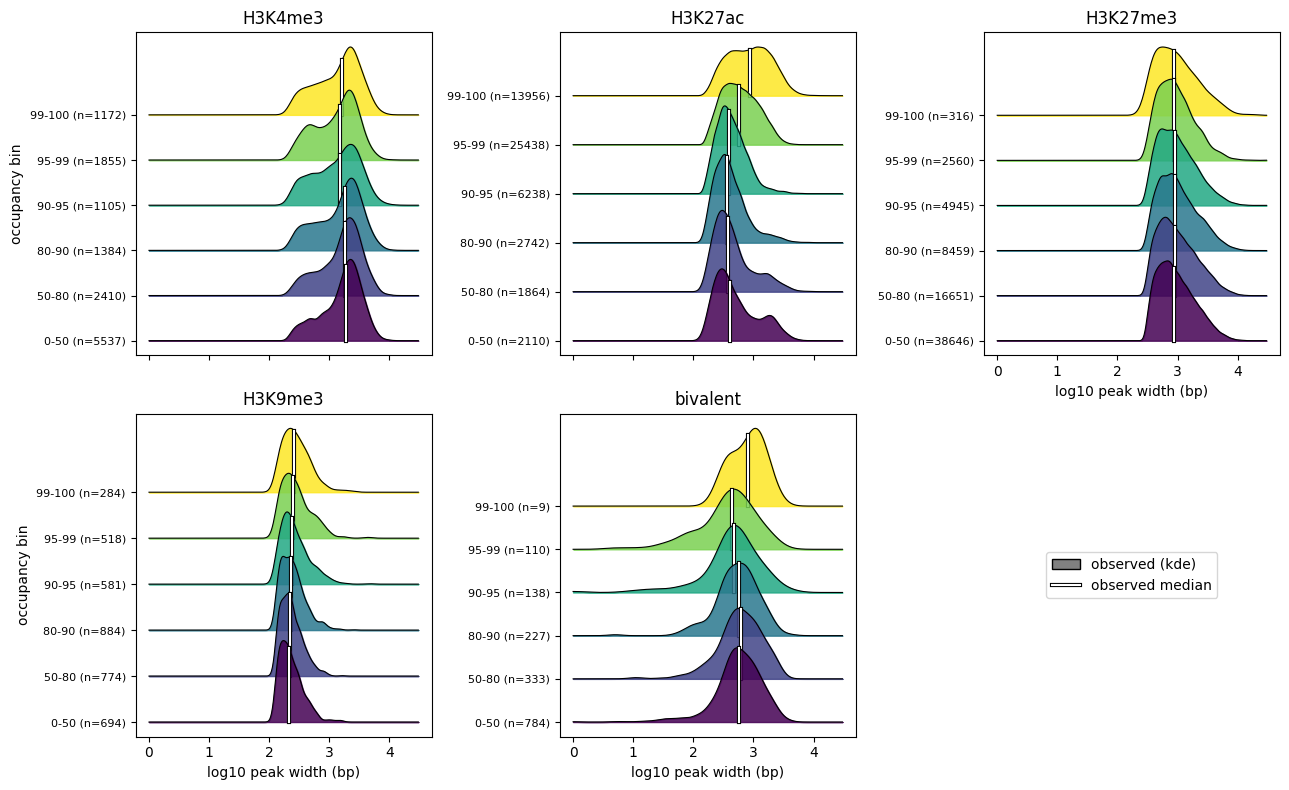

In [16]:
# WITHOUT NULL

median_outline = [pe.withStroke(linewidth=3, foreground='black')]

x_grid = np.linspace(widths_obs['log_width'].min(), widths_obs['log_width'].max(), 300)
bin_colours = plt.cm.viridis(np.linspace(0, 1, len(bin_order)))
overlap = 1.8  # how far the tallest ridge reaches into the one above it

def ridge_density(x):
    if len(x) < 5 or np.std(x) == 0:
        return None
    return gaussian_kde(x)(x_grid)

fig, axes = plt.subplots(2, 3, figsize=(13, 8), sharex=True)
axes = axes.ravel()

for ax, mark_name in zip(axes, marks):
    dens_obs = {b: ridge_density(obs_w.get((mark_name, b), none)) for b in bin_order}
    scale = overlap / max(d.max() for d in dens_obs.values() if d is not None)

    for i, (b, colour) in enumerate(zip(bin_order, bin_colours)):
        z = 10 * (len(bin_order) - i)  # lower ridges drawn in front of higher ones
        if dens_obs[b] is not None:
            top = i + dens_obs[b] * scale
            ax.fill_between(x_grid, i, top, color=colour, alpha=0.85, zorder=z)
            ax.plot(x_grid, top, color='black', linewidth=0.8, zorder=z + 1)

            med = np.median(obs_w[(mark_name, b)])
            ax.plot([med, med], [i, i + np.interp(med, x_grid, dens_obs[b]) * scale],
                    color='white', linewidth=1.5, zorder=z + 2, path_effects=median_outline)

    ax.set_yticks(range(len(bin_order)))
    ax.set_yticklabels([f"{b} (n={len(obs_w.get((mark_name, b), none))})" for b in bin_order], fontsize=8)
    ax.set_title(mark_name)

# spare panel holds the legend
axes[-1].axis('off')
axes[-1].legend(
    handles=[
        Patch(facecolor='grey', edgecolor='black', label='observed (kde)'),
        Line2D([0], [0], color='white', linewidth=1.5, label='observed median', path_effects=median_outline),
    ],
    loc='center'
)

for ax in axes[2:5]:
    ax.set_xlabel('log10 peak width (bp)')
    ax.tick_params(labelbottom=True)
for ax in axes[::3]:
    ax.set_ylabel('occupancy bin')

plt.tight_layout()
plt.savefig('plot_peak_width_ridgeline.png', dpi=300)
plt.show()